# Part A: Non-learned baseline
Produce landmark estimates without training anything. A mean shape fitted to the detected face box, a point distribution model, or an off-the-shelf pre-trained predictor are all acceptable. State which you chose and what it assumes.

If your baseline was trained by someone else, that is fine. Note what it was trained on, since that bears on the Part C comparison. If the point sets do not match, state how you handled it and which points you evaluated on.

Report NME overall and per attribute subset.

## 1. 준비: 라이브러리 + 설정

In [ ]:
import sys, os
sys.path.append(os.path.abspath("../.."))

In [ ]:
from src.data.wflw_annotation_repository import parse_annotation
from src.application.baseline_use_case import compute_mean_shape, predict
from src.shared.nme_metrics import nme_batch, report_by_subset
from src.settings import DataConfig, EvalConfig

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# config
data_config = DataConfig()
eval_config = EvalConfig()

## 2. Mean shape 계산 + 예측

In [ ]:
# 학습셋 전체로 mean shape 계산 (학습이 아니라 통계량)
train = parse_annotation(data_config.train_txt, data_config.images)
mean_shape = compute_mean_shape(train["landmarks"], train["bboxes"])
print("train n =", len(train["paths"]), " mean_shape shape =", mean_shape.shape)

test = parse_annotation(data_config.test_txt, data_config.images)
gts, boxes, masks = test["landmarks"], test["bboxes"], test["subset_masks"]
print("test n =", len(test["paths"]))

In [31]:
preds = predict(mean_shape, boxes)
preds.shape

(2500, 98, 2)

## 3. NME 평가 (3종 정규화 x 전체/attribute subset)

In [ ]:
# 3종 정규화(inter_ocular / inter_pupil / bbox_diag) 모두 계산.
# 주 리포트는 inter_ocular(문헌 관례), thr는 config의 eval.failure_thr.
threshold = eval_config.failure_threshold

def print_table(name, nmes, masks, threshold):
    rows = report_by_subset(nmes, masks, threshold)
    print(f"\n=== {name}  (threshold={threshold}) ===")
    print(f"{'subset':14s} {'NME':>8s} {'fail%':>8s}")
    for k, (m, fr), in rows.items():
        print(f"{k:14s} {m:8.4f} {fr*100:8.2f}")
    return rows

In [34]:
results_by_norm = {}
for norm in ["inter_ocular", "inter_pupil", "bbox_diag"]:
    nme, pp = nme_batch(preds, gts, norm, boxes)
    results_by_norm[norm] = (nme, pp)
    print_table(f"Part A (mean-shape) [{norm}]", nme, masks, threshold)


=== Part A (mean-shape) [inter_ocular]	(threshold=0.1 ===)
subset              NME    fail%
overall          0.2700    89.68
pose             0.6052   100.00
expression       0.2900    96.18
illumination     0.2442    87.39
make-up          0.2298    87.86
occlusion        0.2597    89.13
blur             0.2714    91.59

=== Part A (mean-shape) [inter_pupil]	(threshold=0.1 ===)
subset              NME    fail%
overall          0.3913    97.56
pose             0.9154   100.00
expression       0.4155   100.00
illumination     0.3494    97.28
make-up          0.3297    97.57
occlusion        0.3718    97.15
blur             0.3941    97.54

=== Part A (mean-shape) [bbox_diag]	(threshold=0.1 ===)
subset              NME    fail%
overall          0.0880    34.96
pose             0.1463    97.24
expression       0.0962    42.36
illumination     0.0830    29.37
make-up          0.0810    30.10
occlusion        0.0880    33.70
blur             0.0905    37.90


## 4. subset별 NME 시각화 + 실패 사례 오버레이

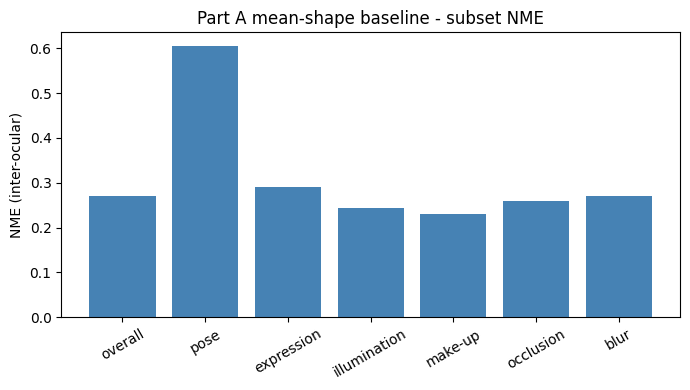

In [36]:
%matplotlib inline
# 주 정규화(inter_ocular) 기준 subset별 NME 막대그래프
nme, _ = results_by_norm["inter_ocular"]
rows = report_by_subset(nme, masks, threshold)
names = list(rows.keys())
vals = [rows[k][0] for k in names]

plt.figure(figsize=(7, 4))
plt.bar(names, vals, color="steelblue")
plt.ylabel("NME (inter-ocular)")
plt.title("Part A mean-shape baseline - subset NME")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


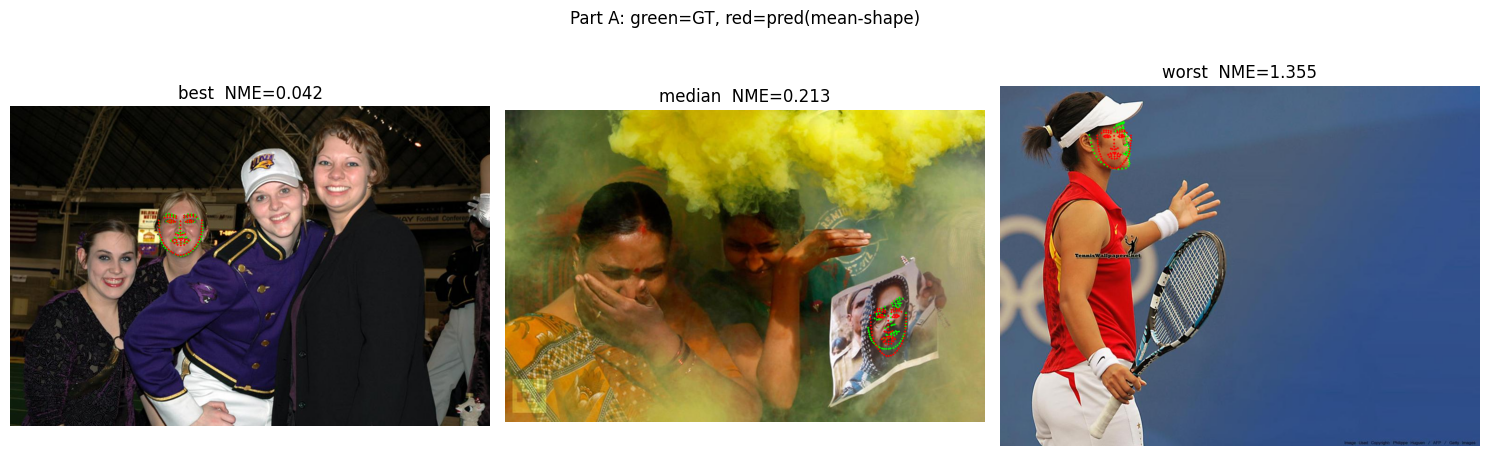

In [40]:
# 예측(빨간) vs 정답(초록) 오버레이: best / median / worst 3장
order = np.argsort(nme)
picks = {"best": order[0], "median": order[len(order)//2], "worst": order[-1]}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (tag, i) in zip(axes, picks.items()):
    img = cv2.cvtColor(cv2.imread(test["paths"][i]), cv2.COLOR_BGR2RGB).copy()
    for (x, y) in gts[i]:
        cv2.circle(img, (int(x), int(y)), 2, (0, 255, 0), -1)
    for (x, y) in preds[i]:
        cv2.circle(img, (int(x), int(y)), 2, (255, 0, 0), -1)
    ax.imshow(img)
    ax.set_title(f"{tag}  NME={nme[i]:.3f}")
    ax.axis("off")
fig.suptitle("Part A: green=GT, red=pred(mean-shape)")
fig.tight_layout()
plt.show()

## 5. yaw(large-pose) 여부에 따른 NME 비교

In [41]:
# yaw(측면각) 커질수록 mean-shape가 단조증가하는지 간단 확인
# (Part C의 정식 yaw-PnP 파생과는 별개로, 여기서는 large-pose 이진 flag로만 빠르게 확인)
large_pose = masks["pose"]
print("large-pose 이미지 수:", large_pose.sum(), "/", len(large_pose))
print(f"NME (large-pose=True)  : {nme[large_pose].mean():.4f}")
print(f"NME (large-pose=False) : {nme[~large_pose].mean():.4f}")

large-pose 이미지 수: 326 / 2500
NME (large-pose=True)  : 0.6052
NME (large-pose=False) : 0.2197
